## Optimization code for multilayer or graded porous structure for broadband absorption

#### Input parameters:
- Number of layers
- Layer thickness
- Density of the layer

In [1]:
import numpy as np
from scipy.optimize import minimize

def jca_properties(freq, phi, sigma, alpha_inf, Lambda, Lambda_prime):
    """Calculates Zc and k using the Johnson-Champoux-Allard model."""
    omega = 2 * np.pi * freq
    rho_0 = 1.21  # Air density
    P_0 = 101325  # Atmospheric pressure
    gamma = 1.4
    Pr = 0.71
    mu = 1.84e-5
    
    # Dynamic density (Johnson et al.)
    rho_omega = (alpha_inf * rho_0 / phi) * (1 + (sigma * phi) / (1j * omega * rho_0 * alpha_inf) * np.sqrt(1 + (4 * 1j * alpha_inf**2 * mu * rho_0 * omega) / (sigma**2 * Lambda**2 * phi**2)))
    
    # Dynamic bulk modulus (Champoux-Allard)
    K_omega = (gamma * P_0 / phi) / (gamma - (gamma - 1) / 
               (1 + (8 * mu) / (1j * omega * Pr * rho_0 * Lambda_prime**2) * np.sqrt(1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * mu))))
    
    Zc = np.sqrt(rho_omega * K_omega)
    k = omega * np.sqrt(rho_omega / K_omega)
    return Zc, k

def get_layer_matrix(Zc, k, d):
    """Returns the 2x2 Transfer Matrix for a layer of thickness d."""
    T = np.zeros((2, 2), dtype=complex)
    T[0, 0] = np.cos(k * d)
    T[0, 1] = 1j * Zc * np.sin(k * d)
    T[1, 0] = (1j / Zc) * np.sin(k * d)
    T[1, 1] = np.cos(k * d)
    return T

### Three options to define function: 

$\texttt{interpolate\_jca\_from\_granulometry}$

1. The "Discrete Index" Approach (Simplest): \
If only intend to use the four exact granulometries already characterized (Coarse, Medium, Fine, Extra-fine), use a simple lookup table.Advice: Use of a dictionary to store the average values found in Table 7 of the paper. 
 Code Tip: Use np.round or an integer cast to map the optimizer's continuous output to your discrete choices.

```python
def interpolate_jca_from_granulometry(index):
    # Map optimizer's 1.0-4.0 range to specific granulometries
    # 1: Coarse, 2: Medium, 3: Fine, 4: Extra-fine
    data = {
        1: {'phi': 0.41, 'alpha_inf': 1.94, 'sigma': 5377, 'Lambda': 211e-6, 'Lambda_p': 221e-6},
        2: {'phi': 0.45, 'alpha_inf': 1.62, 'sigma': 14811, 'Lambda': 86e-6, 'Lambda_p': 102e-6},
        # ... and so on for Fine/Extra-fine from Table 7
    }
    idx = int(np.clip(np.round(index), 1, 4))
    res = data[idx]
    return res['phi'], res['sigma'], res['alpha_inf'], res['Lambda'], res['Lambda_p']

```

2. The "Morpho-Density" Regression (Recommended for Article 2):\
In your first paper, you found a strong correlation between the characteristic lengths ($\Lambda$, $\Lambda'$) and a variable related to particle dimension, sphericity, and density. Using these regressions makes your second article much more scientifically powerful because it shows you aren't just "guessing" parameters—you are predicting them based on morphology.
Tip: Use Equation 14 from your paper to link density ($\rho$) to porosity ($\phi$).
Tip: Use the Modified Kozeny-Carman formulation (Eq. 18) to calculate airflow resistivity ($\sigma$) based on your equivalent particle diameters ($d_{\text{mean}}$).

3. Key Findings to Include in your Logic:Porosity ($\phi$): \
Your paper shows that porosity increases as granulometry becomes finer. Ensure your interpolation reflects that $\phi$ moves from ~0.41 (Coarse) to ~0.57 (Extra-fine).  Flow Resistivity ($\sigma$): You noted that $\sigma$ increases significantly when granulometry becomes finer, as smaller particles form more compacted structures. In your code, $\sigma$ should scale with $1/d_{mean}^2$ following the Kozeny-Carman logic you validated.  Tortuosity ($\alpha_{\infty}$): Finer granulometries result in higher tortuosity because the acoustic wave follows a longer path. You can use Archie's Law (Eq. 22) with the $\xi$ values you calculated (e.g., 0.41 for Coarse, 2.24 for Extra-fine) to interpolate $\alpha_{\infty}$ dynamically.  

Connection to previous article: "The JCA parameters for the multilayer optimization were determined by interpolating the experimental data retrieved in. Specifically, porosity and tortuosity were linked to the granulometry and density through the linear regressions and Archie’s law coefficients established in the previous characterization." 

In [2]:

import numpy as np
from scipy.optimize import minimize

def interpolate_jca_from_granulometry(index):
    """
    Mapping the optimizer's 'index' to the physical parameters 
    found in your first paper.
    """
    # 1. Reference Data from Paper 1 (Tables 3 & 4)
    # Indices: 1=Coarse, 2=Medium, 3=Fine, 4=Extra-fine
    indices = [1, 2, 3, 4]
    
    # Particle Densities (kg/m^3)
    rho_p_vals = [540.1, 630.2, 691.3, 944.3]
    # Equivalent Particle Diameters (m)
    d_part_vals = [3.54e-3, 2.41e-3, 1.50e-3, 0.50e-3]
    # Archie's Law exponents (xi)
    xi_vals = [0.41, 0.82, 1.06, 2.24]
    # Representative Bulk Densities (kg/m^3) - Typical for your samples
    bulk_rho_vals = [285, 315, 320, 360]

    # 2. Interpolate based on the index provided by the optimizer
    rho_p = np.interp(index, indices, rho_p_vals)
    d_mean = np.interp(index, indices, d_part_vals)
    xi = np.interp(index, indices, xi_vals)
    rho_bulk = np.interp(index, indices, bulk_rho_vals)

    # 3. Calculate JCA Parameters
    phi = 1 - (rho_bulk / rho_p)      # Porosity (Eq. 14)
    alpha_inf = phi**(-xi)            # Tortuosity (Eq. 22)
    
    # Airflow resistivity (Simplified Kozeny-Carman)
    mu = 1.84e-5
    Kc = 5.0 # Kozeny constant calibrated in your paper
    sigma = Kc * (mu / d_mean**2) * ((1 - phi)**2 / phi**3)

    # Characteristic Lengths
    # Using the correlations you observed in the conclusion of Paper 1
    Lambda_prime = d_mean / 2.0
    Lambda = Lambda_prime / 1.5 

    return phi, sigma, alpha_inf, Lambda, Lambda_prime

def objective_function(design_params, freq_range, total_thickness, num_layers):
    """
    Now calls interpolate_jca_from_granulometry with only one argument.
    """
    d_layer = total_thickness / num_layers
    total_absorption = []
    
    for f in freq_range:
        T_total = np.eye(2, dtype=complex)
        
        for i in range(num_layers):
            # No 'density' argument needed here now, it's handled inside!
            params = interpolate_jca_from_granulometry(design_params[i]) 
            
            Zc, k = jca_properties(f, *params)
            T_n = get_layer_matrix(Zc, k, d_layer)
            T_total = np.matmul(T_total, T_n)
        
        # Surface Impedance & Absorption
        Zs = T_total[0, 0] / T_total[1, 0]
        Z0 = 413.5 
        R = (Zs - Z0) / (Zs + Z0)
        alpha = 1 - np.abs(R)**2
        total_absorption.append(alpha)
    
    # We want to minimize (1 - average absorption)
    return 1 - np.mean(total_absorption)


PURE GRANULOMETRY OPTIMIZED DESIGN
Layer Sequence:    ['Coarse', 'Medium', 'Fine', 'Extra-Fine']
Layer Thicknesses: [ 5.  5. 10. 30.] mm
Mean Absorption:   0.698


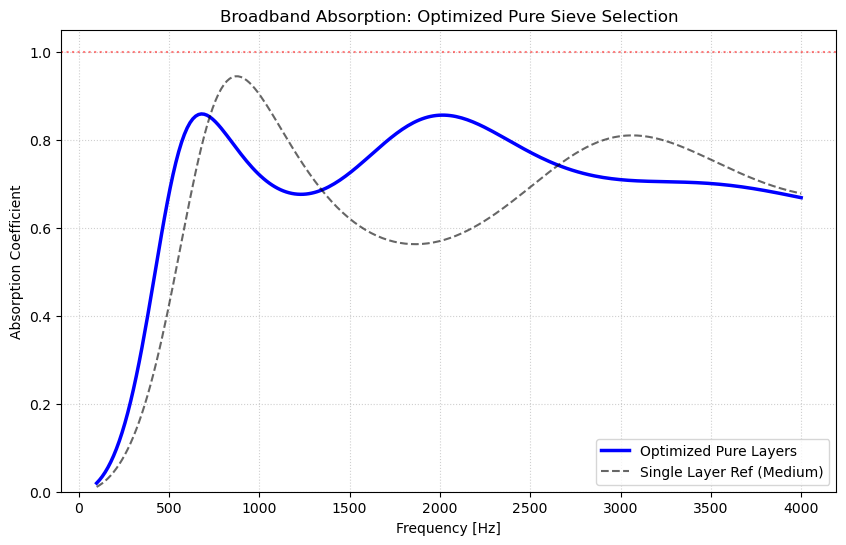

In [3]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import matplotlib.pyplot as plt

# =================================================================
# 1. ACOUSTIC PHYSICS (JCA MODEL & TMM)
# =================================================================
def jca_properties(f, phi, sigma, alpha_inf, Lambda, Lambda_prime):
    omega = 2 * np.pi * f
    rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5
    rho_e = (alpha_inf * rho_0 / phi) * (1 + (sigma * phi) / (1j * omega * rho_0 * alpha_inf) * np.sqrt(1 + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega) / (sigma**2 * Lambda**2 * phi**2)))
    K_e = (gamma * P_0 / phi) / (gamma - (gamma - 1) / (1 + (8 * eta) / (1j * omega * Pr * rho_0 * Lambda_prime**2) * np.sqrt(1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta))))
    return np.sqrt(rho_e * K_e), omega * np.sqrt(rho_e / K_e)

def get_layer_matrix(Zc, k, d):
    T = np.zeros((2, 2), dtype=complex)
    T[0, 0], T[0, 1] = np.cos(k * d), 1j * Zc * np.sin(k * d)
    T[1, 0], T[1, 1] = (1j / Zc) * np.sin(k * d), np.cos(k * d)
    return T

# =================================================================
# 2. MATERIAL CHARACTERIZATION (Pure Granulometry Only)
# =================================================================
def get_pure_jca(index):
    """
    Returns JCA parameters for PURE granulometry only.
    index: 1=Coarse, 2=Medium, 3=Fine, 4=Extra-fine
    """
    # Using the specific values from your Table 7 (validated data)
    data = {
        1: {'phi': 0.41, 'alpha': 1.94, 'sigma': 5377,  'L': 211e-6, 'Lp': 221e-6},
        2: {'phi': 0.45, 'alpha': 1.62, 'sigma': 14811, 'L': 86e-6,  'Lp': 102e-6},
        3: {'phi': 0.54, 'alpha': 1.63, 'sigma': 19934, 'L': 71e-6,  'Lp': 85e-6},
        4: {'phi': 0.57, 'alpha': 2.50, 'sigma': 41344, 'L': 38e-6,  'Lp': 47e-6}
    }
    # Round to nearest integer to force "pure" selection
    idx = int(np.clip(np.round(index), 1, 4))
    res = data[idx]
    return res['phi'], res['sigma'], res['alpha'], res['L'], res['Lp']

# =================================================================
# 3. ABSORPTION CALCULATION
# =================================================================
def calculate_absorption_curve(design_params, freq_range, num_layers):
    indices = design_params[:num_layers]
    thicknesses = design_params[num_layers:]
    
    absorption_curve = []
    for f in freq_range:
        T_total = np.eye(2, dtype=complex)
        for i in range(num_layers):
            # Calls the PURE granulometry function
            params = get_pure_jca(indices[i])
            Zc, k = jca_properties(f, *params)
            T_n = get_layer_matrix(Zc, k, thicknesses[i])
            T_total = np.matmul(T_total, T_n)
        
        Zs = T_total[0, 0] / T_total[1, 0]
        R = (Zs - 413.5) / (Zs + 413.5)
        absorption_curve.append(1 - np.abs(R)**2)
    return np.array(absorption_curve)

def objective_function(design_params, freq_range, num_layers):
    alpha_curve = calculate_absorption_curve(design_params, freq_range, num_layers)
    return 1 - np.mean(alpha_curve)

# =================================================================
# 4. SETTINGS & EXECUTION
# =================================================================
NUM_LAYERS = 4
TOTAL_THICKNESS = 0.05   # in meters 
FREQS = np.linspace(100, 4000, 250)

# Constraints for thickness sum
A = np.zeros(NUM_LAYERS * 2); A[NUM_LAYERS:] = 1  
constraint = LinearConstraint(A, TOTAL_THICKNESS, TOTAL_THICKNESS)
bounds = [(1.0, 4.0)] * NUM_LAYERS + [(0.005, 0.030)] * NUM_LAYERS

# Optimization
# We start with a reasonable guess for layers
initial_guess = [1, 2, 3, 4] + [TOTAL_THICKNESS/NUM_LAYERS]*NUM_LAYERS

res = minimize(objective_function, initial_guess, args=(FREQS, NUM_LAYERS), 
               method='trust-constr', bounds=bounds, constraints=constraint)

# =================================================================
# 5. RESULTS & PLOTTING
# =================================================================
# Round the indices for the final result plot
final_params = res.x.copy()
final_params[:NUM_LAYERS] = np.round(final_params[:NUM_LAYERS])

opt_alpha = calculate_absorption_curve(final_params, FREQS, NUM_LAYERS)
ref_alpha = calculate_absorption_curve([2.0, TOTAL_THICKNESS], FREQS, 1) # Single Medium layer

# Mapping names for output
names = {1: "Coarse", 2: "Medium", 3: "Fine", 4: "Extra-Fine"}
opt_names = [names[int(i)] for i in final_params[:NUM_LAYERS]]

print("\n" + "="*45)
print("PURE GRANULOMETRY OPTIMIZED DESIGN")
print("="*45)
print(f"Layer Sequence:    {opt_names}")
print(f"Layer Thicknesses: {np.round(final_params[NUM_LAYERS:] * 1000, 1)} mm")
print(f"Mean Absorption:   {np.mean(opt_alpha):.3f}")
print("="*45)

plt.figure(figsize=(10, 6))
plt.plot(FREQS, opt_alpha, color='blue', linewidth=2.5, label='Optimized Pure Layers')
plt.plot(FREQS, ref_alpha, color='black', linestyle='--', alpha=0.6, label='Single Layer Ref (Medium)')
plt.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
plt.title('Broadband Absorption: Optimized Pure Sieve Selection')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Absorption Coefficient')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.ylim(0, 1.05)
plt.show()

Starting Global Search (20 iterations)...
  > Iteration 0: Found better configuration (Mean Alpha: 0.709)
    Layer Order: ['Fine', 'Coarse', 'Coarse', 'Fine']
    Thicknesses: [21.4  5.   5.  18.6] mm
  > Iteration 1: Found better configuration (Mean Alpha: 0.714)
    Layer Order: ['Fine', 'Medium', 'Fine', 'Fine']
    Thicknesses: [20.4  9.3 10.9  9.4] mm


c:\Users\J.Garcia\anaconda3\Lib\site-packages\scipy\optimize\_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


  > Iteration 2: Found better configuration (Mean Alpha: 0.722)
    Layer Order: ['Fine', 'Extra-Fine', 'Medium', 'Fine']
    Thicknesses: [18.5  8.4 10.5 12.6] mm
  > Iteration 14: Found better configuration (Mean Alpha: 0.728)
    Layer Order: ['Fine', 'Medium', 'Extra-Fine', 'Medium']
    Thicknesses: [15.9  5.  24.1  5. ] mm

FINAL OPTIMIZED PURE-SIEVE DESIGN
Layer Order (Front->Back): ['Fine', 'Medium', 'Extra-Fine', 'Medium']
Layer Thicknesses (mm):    [15.9  5.  24.1  5. ]
Mean Alpha (Optimized):    0.728
Mean Alpha (Single Layer): 0.658
Mean Alpha (Fine):         0.712
Mean Alpha (Extra-Fine):   0.617
Mean Alpha (Coarse):       0.575


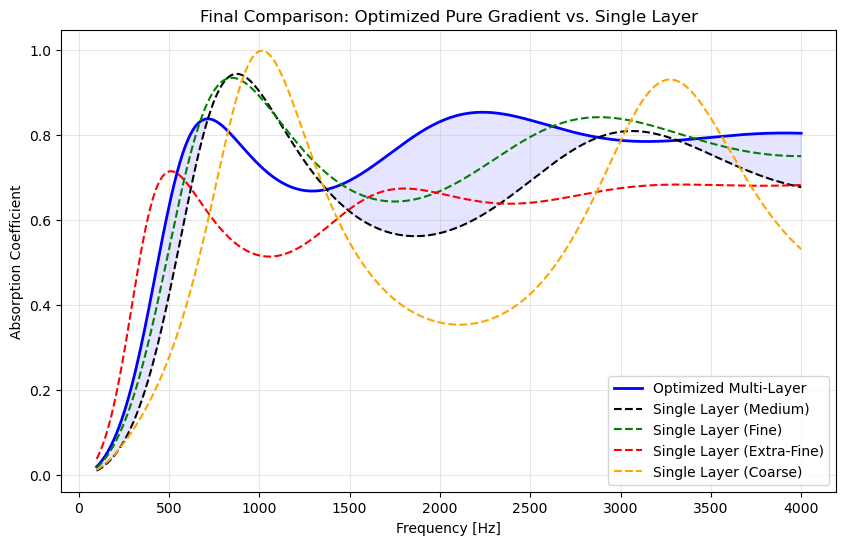

In [18]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import matplotlib.pyplot as plt
import random

# =================================================================
# 1. CORE PHYSICS (JCA MODEL & TMM)
# =================================================================
def jca_properties(f, phi, sigma, alpha_inf, Lambda, Lambda_prime):
    omega = 2 * np.pi * f
    rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5
    rho_e = (alpha_inf * rho_0 / phi) * (1 + (sigma * phi) / (1j * omega * rho_0 * alpha_inf) * np.sqrt(1 + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega) / (sigma**2 * Lambda**2 * phi**2)))
    K_e = (gamma * P_0 / phi) / (gamma - (gamma - 1) / (1 + (8 * eta) / (1j * omega * Pr * rho_0 * Lambda_prime**2) * np.sqrt(1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta))))
    return np.sqrt(rho_e * K_e), omega * np.sqrt(rho_e / K_e)

def get_layer_matrix(Zc, k, d):
    T = np.zeros((2, 2), dtype=complex)
    T[0, 0], T[0, 1] = np.cos(k * d), 1j * Zc * np.sin(k * d)
    T[1, 0], T[1, 1] = (1j / Zc) * np.sin(k * d), np.cos(k * d)
    return T

# =================================================================
# 2. PURE GRANULOMETRY DATA (From Paper 1 Table 7)
# =================================================================
def get_pure_jca(index):
    # We round the index to the nearest integer to ensure we only use pure sieves
    idx = int(np.clip(np.round(index), 1, 4))
    data = {
        1: {'phi': 0.41, 'sigma': 5377,  'alpha': 1.94, 'L': 211e-6, 'Lp': 221e-6}, # Coarse
        2: {'phi': 0.45, 'sigma': 14811, 'alpha': 1.62, 'L': 86e-6,  'Lp': 102e-6}, # Medium
        3: {'phi': 0.54, 'sigma': 19934, 'alpha': 1.63, 'L': 71e-6,  'Lp': 85e-6},  # Fine
        4: {'phi': 0.57, 'sigma': 41344, 'alpha': 2.50, 'L': 38e-6,  'Lp': 47e-6}   # Extra-Fine
    }
    res = data[idx]
    return res['phi'], res['sigma'], res['alpha'], res['L'], res['Lp']

# =================================================================
# 3. ABSORPTION CALCULATION
# =================================================================
def calculate_absorption_curve(design_params, freq_range, num_layers):
    indices = design_params[:num_layers]
    thicknesses = design_params[num_layers:]
    
    absorption_curve = []
    for f in freq_range:
        T_total = np.eye(2, dtype=complex)
        for i in range(num_layers):
            params = get_pure_jca(indices[i])
            Zc, k = jca_properties(f, *params)
            T_n = get_layer_matrix(Zc, k, thicknesses[i])
            T_total = np.matmul(T_total, T_n)
        
        Zs = T_total[0, 0] / T_total[1, 0]
        R = (Zs - 413.5) / (Zs + 413.5)
        absorption_curve.append(1 - np.abs(R)**2)
    return np.array(absorption_curve)

def objective_function(design_params, freq_range, num_layers):
    alpha_curve = calculate_absorption_curve(design_params, freq_range, num_layers)
    return 1 - np.mean(alpha_curve)

# =================================================================
# 4. OPTIMIZATION WITH GLOBAL ITERATIONS
# =================================================================
NUM_LAYERS = 4
TOTAL_THICKNESS = 0.05 
FREQS = np.linspace(100, 4000, 500)

A = np.zeros(NUM_LAYERS * 2); A[NUM_LAYERS:] = 1  
constraint = LinearConstraint(A, TOTAL_THICKNESS, TOTAL_THICKNESS)
bounds = [(1.0, 4.0)] * NUM_LAYERS + [(0.005, 0.030)] * NUM_LAYERS

best_cost = 1.0
best_params = None
num_random_searches = 20 # Iterating 20 times to find the best order/thickness

print(f"Starting Global Search ({num_random_searches} iterations)...")

for i in range(num_random_searches):
    # Random Granulometry Order (Pure integers 1-4)
    rand_indices = [float(random.randint(1, 4)) for _ in range(NUM_LAYERS)]
    # Random Thicknesses summing to TOTAL_THICKNESS
    rand_thicks = np.random.dirichlet(np.ones(NUM_LAYERS), size=1)[0] * TOTAL_THICKNESS
    
    current_guess = list(rand_indices) + list(rand_thicks)
    
    # Local optimization for this random start
    temp_res = minimize(objective_function, current_guess, args=(FREQS, NUM_LAYERS), 
                        method='trust-constr', bounds=bounds, constraints=constraint,
                        options={'maxiter': 50, 'verbose': 0})
    
    if temp_res.fun < best_cost:
        best_cost = temp_res.fun
        best_params = temp_res.x
        print(f"  > Iteration {i}: Found better configuration (Mean Alpha: {1-best_cost:.3f})")
        names = {1: "Coarse", 2: "Medium", 3: "Fine", 4: "Extra-Fine"}
        print(f"    Layer Order: {[names[int(np.round(idx))] for idx in best_params[:NUM_LAYERS]]}")
        print(f"    Thicknesses: {np.round(best_params[NUM_LAYERS:] * 1000, 1)} mm")

# Final Polish of the best result
res = minimize(objective_function, best_params, args=(FREQS, NUM_LAYERS), 
               method='trust-constr', bounds=bounds, constraints=constraint)

# =================================================================
# 5. RESULTS & COMPARISON
# =================================================================
final_params = res.x.copy()
final_params[:NUM_LAYERS] = np.round(final_params[:NUM_LAYERS]) # Force final result to integers

opt_alpha = calculate_absorption_curve(final_params, FREQS, NUM_LAYERS)
# Single layer Medium (Index 2) reference
ref_alpha = calculate_absorption_curve([2.0] + [TOTAL_THICKNESS], FREQS, 1)
ref_alpha2 = calculate_absorption_curve([3.0] + [TOTAL_THICKNESS], FREQS, 1) # Single layer Fine reference
ref_alpha3 = calculate_absorption_curve([4.0] + [TOTAL_THICKNESS], FREQS, 1) # Single layer Extra-Fine reference
ref_alpha4 = calculate_absorption_curve([1.0] + [TOTAL_THICKNESS], FREQS, 1) # Single layer Coarse reference

names = {1: "Coarse", 2: "Medium", 3: "Fine", 4: "Extra-Fine"}
opt_names = [names[int(i)] for i in final_params[:NUM_LAYERS]]

print("\n" + "="*45)
print("FINAL OPTIMIZED PURE-SIEVE DESIGN")
print("="*45)
print(f"Layer Order (Front->Back): {opt_names}")
print(f"Layer Thicknesses (mm):    {np.round(final_params[NUM_LAYERS:] * 1000, 1)}")
print(f"Mean Alpha (Optimized):    {np.mean(opt_alpha):.3f}")
print(f"Mean Alpha (Single Layer): {np.mean(ref_alpha):.3f}")
print(f"Mean Alpha (Fine):         {np.mean(ref_alpha2):.3f}")
print(f"Mean Alpha (Extra-Fine):   {np.mean(ref_alpha3):.3f}")
print(f"Mean Alpha (Coarse):       {np.mean(ref_alpha4):.3f}")
print("="*45)

plt.figure(figsize=(10, 6))
plt.plot(FREQS, opt_alpha, color='blue', linewidth=2, label='Optimized Multi-Layer')
plt.plot(FREQS, ref_alpha, color='black', linestyle='--', label='Single Layer (Medium)')
plt.plot(FREQS, ref_alpha2, color='green', linestyle='--', label='Single Layer (Fine)')
plt.plot(FREQS, ref_alpha3, color='red', linestyle='--', label='Single Layer (Extra-Fine)')
plt.plot(FREQS, ref_alpha4, color='orange', linestyle='--', label='Single Layer (Coarse)')
plt.fill_between(FREQS, opt_alpha, ref_alpha, where=(opt_alpha > ref_alpha), color='blue', alpha=0.1)
plt.title('Final Comparison: Optimized Pure Gradient vs. Single Layer')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Absorption Coefficient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Evaluating all 1024 layer configurations with continuous SLSQP optimization...

GLOBAL OPTIMIZATION RESULT
Optimal Layer Order (Front -> Back): ['Coarse', 'Fine', 'Extra-Fine', 'Fine', 'Extra-Fine']
Optimal Thicknesses (mm):           [ 3.   13.39  8.81  4.22 20.58]
Mean Absorption Coefficient (Opt):   0.738
Mean Absorption (Single Medium):    0.658
Mean Absorption (Single Fine):      0.712
Mean Absorption (Single Extra-Fine): 0.617
Mean Absorption (Single Coarse):    0.575


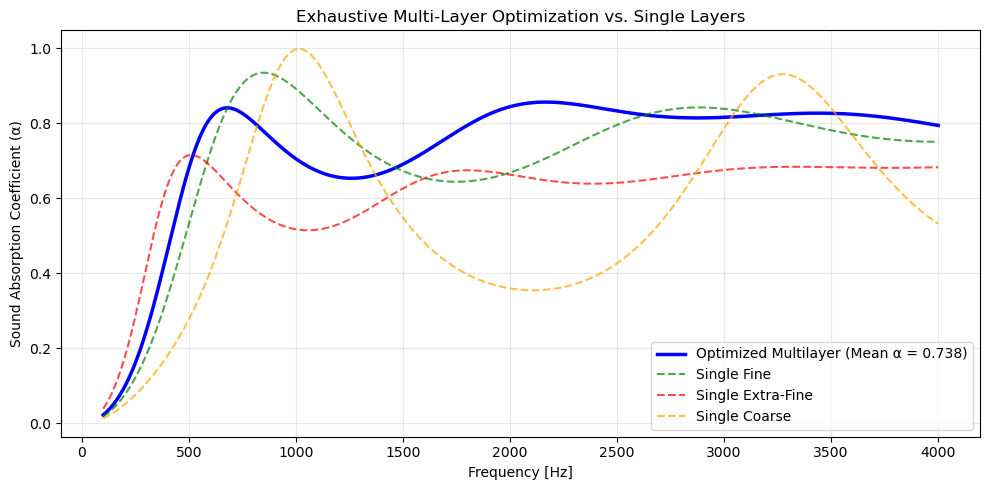

In [28]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

# =================================================================
# 1. CORE PHYSICS (VECTORIZED JCA & TMM)
# =================================================================
# Material Database (Table 7)
MATERIALS = {
    1: {
        'name': 'Coarse',
        'phi': 0.41,
        'sigma': 5377,
        'alpha': 1.94,
        'L': 211e-6,
        'Lp': 221e-6,
    },
    2: {
        'name': 'Medium',
        'phi': 0.45,
        'sigma': 14811,
        'alpha': 1.62,
        'L': 86e-6,
        'Lp': 102e-6,
    },
    3: {
        'name': 'Fine',
        'phi': 0.54,
        'sigma': 19934,
        'alpha': 1.63,
        'L': 71e-6,
        'Lp': 85e-6,
    },
    4: {
        'name': 'Extra-Fine',
        'phi': 0.57,
        'sigma': 41344,
        'alpha': 2.50,
        'L': 38e-6,
        'Lp': 47e-6,
    },
}


def jca_properties_vec(f_vec, phi, sigma, alpha_inf, Lambda, Lambda_prime):
  """Vectorized JCA acoustic property evaluation over all frequencies."""
  omega = 2 * np.pi * f_vec
  rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5

  rho_e = (alpha_inf * rho_0 / phi) * (
      1
      + (sigma * phi)
      / (1j * omega * rho_0 * alpha_inf)
      * np.sqrt(
          1
          + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega)
          / (sigma**2 * Lambda**2 * phi**2)
      )
  )
  K_e = (gamma * P_0 / phi) / (
      gamma
      - (gamma - 1)
      / (
          1
          + (8 * eta)
          / (1j * omega * Pr * rho_0 * Lambda_prime**2)
          * np.sqrt(
              1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta)
          )
      )
  )

  Zc = np.sqrt(rho_e * K_e)
  k = omega * np.sqrt(rho_e / K_e)
  return Zc, k


def calculate_absorption_vectorized(thicknesses, material_indices, freq_range, Z0=413.5):
    
  """Calculates absorption spectrum via Transfer Matrix Method using vectorized operations."""
  
  num_freqs = len(freq_range)

  # Pre-initialize Transfer Matrices for all frequencies [N_freq, 2, 2]
  T_total = np.zeros((num_freqs, 2, 2), dtype=complex)
  T_total[:, 0, 0] = 1.0
  T_total[:, 1, 1] = 1.0

  for idx, d in zip(material_indices, thicknesses):
    p = MATERIALS[idx]
    Zc, k = jca_properties_vec(
        freq_range, p['phi'], p['sigma'], p['alpha'], p['L'], p['Lp']
    )

    # Layer Transfer Matrix elements across frequencies
    cos_kd = np.cos(k * d)
    sin_kd = np.sin(k * d)

    T_layer = np.zeros((num_freqs, 2, 2), dtype=complex)
    T_layer[:, 0, 0] = cos_kd
    T_layer[:, 0, 1] = 1j * Zc * sin_kd
    T_layer[:, 1, 0] = (1j / Zc) * sin_kd
    T_layer[:, 1, 1] = cos_kd

    # Batch matrix multiplication: T_total = T_total @ T_layer
    T_total = np.einsum('nij,njk->nik', T_total, T_layer)

  Zs = T_total[:, 0, 0] / T_total[:, 1, 0]
  R = (Zs - Z0) / (Zs + Z0)
  return 1.0 - np.abs(R) ** 2


# =================================================================
# 2. HYBRID OPTIMIZATION PIPELINE
# =================================================================
NUM_LAYERS = 5
TOTAL_THICKNESS = 0.05  # 50 mm total
FREQS = np.linspace(100, 4000, 500)
MIN_THICKNESS = 0.003  # 3 mm minimum constraint per layer

# Generate all 256 possible material ordering permutations
all_permutations = list(itertools.product([1, 2, 3, 4], repeat=NUM_LAYERS))

best_global_alpha = -1.0
best_global_config = None
best_global_thicknesses = None

print(
    f'Evaluating all {len(all_permutations)} layer configurations with continuous SLSQP optimization...'
)

bounds = [(MIN_THICKNESS, TOTAL_THICKNESS)] * NUM_LAYERS
constraints = {'type': 'eq', 'fun': lambda d: np.sum(d) - TOTAL_THICKNESS}
initial_thicknesses = np.ones(NUM_LAYERS) * (TOTAL_THICKNESS / NUM_LAYERS)

for perm in all_permutations:

  def sub_objective(d):
    alpha = calculate_absorption_vectorized(d, perm, FREQS)
    return 1.0 - np.mean(alpha)

  res = minimize(
      sub_objective,
      initial_thicknesses,
      method='SLSQP',
      bounds=bounds,
      constraints=constraints,
      options={'ftol': 1e-5, 'maxiter': 100},
  )

  mean_alpha = 1.0 - res.fun
  if mean_alpha > best_global_alpha:
    best_global_alpha = mean_alpha
    best_global_config = perm
    best_global_thicknesses = res.x

# =================================================================
# 3. RESULTS & PLOTTING
# =================================================================
opt_names = [MATERIALS[idx]['name'] for idx in best_global_config]
opt_alpha = calculate_absorption_vectorized(
    best_global_thicknesses, best_global_config, FREQS
)

# Reference Single Layers
ref_medium = calculate_absorption_vectorized([TOTAL_THICKNESS], [2], FREQS)
ref_fine = calculate_absorption_vectorized([TOTAL_THICKNESS], [3], FREQS)
ref_xfine = calculate_absorption_vectorized([TOTAL_THICKNESS], [4], FREQS)
ref_coarse = calculate_absorption_vectorized([TOTAL_THICKNESS], [1], FREQS)

print('\n' + '=' * 50)
print('GLOBAL OPTIMIZATION RESULT')
print('=' * 50)
print(f'Optimal Layer Order (Front -> Back): {opt_names}')
print(
    'Optimal Thicknesses (mm):          '
    f' {np.round(best_global_thicknesses * 1000, 2)}'
)
print(f'Mean Absorption Coefficient (Opt):   {best_global_alpha:.3f}')
print(f'Mean Absorption (Single Medium):    {np.mean(ref_medium):.3f}')
print(f'Mean Absorption (Single Fine):      {np.mean(ref_fine):.3f}')
print(f'Mean Absorption (Single Extra-Fine): {np.mean(ref_xfine):.3f}')
print(f'Mean Absorption (Single Coarse):    {np.mean(ref_coarse):.3f}')
print('=' * 50)

plt.figure(figsize=(10, 5))
plt.plot(
    FREQS,
    opt_alpha,
    color='blue',
    linewidth=2.5,
    label=f'Optimized Multilayer (Mean α = {best_global_alpha:.3f})',
)
plt.plot(
    FREQS,
    ref_fine,
    color='green',
    linestyle='--',
    alpha=0.7,
    label='Single Fine',
)
plt.plot(
    FREQS,
    ref_xfine,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Single Extra-Fine',
)
plt.plot(
    FREQS,
    ref_coarse,
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Single Coarse',
)
plt.title('Exhaustive Multi-Layer Optimization vs. Single Layers')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Sound Absorption Coefficient (α)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Evaluating all 256 configurations and logging SLSQP thickness updates...

=== Permutation 1/256: ['Coarse', 'Coarse', 'Coarse', 'Coarse'] ===
  [Step 01] Order: ['Coarse', 'Coarse', 'Coarse', 'Coarse'] | Thicknesses [mm]: [12.50, 12.50, 12.50, 12.50] | Mean Alpha: 0.5752
  -> Final for ['Coarse', 'Coarse', 'Coarse', 'Coarse']: Mean Alpha = 0.5752, Thicknesses [mm] = [12.5 12.5 12.5 12.5]

=== Permutation 2/256: ['Coarse', 'Coarse', 'Coarse', 'Medium'] ===
  [Step 01] Order: ['Coarse', 'Coarse', 'Coarse', 'Medium'] | Thicknesses [mm]: [3.00, 3.00, 3.00, 41.00] | Mean Alpha: 0.6396
  [Step 02] Order: ['Coarse', 'Coarse', 'Coarse', 'Medium'] | Thicknesses [mm]: [3.00, 3.00, 3.00, 41.00] | Mean Alpha: 0.6396
  -> Final for ['Coarse', 'Coarse', 'Coarse', 'Medium']: Mean Alpha = 0.6396, Thicknesses [mm] = [ 3.  3.  3. 41.]

=== Permutation 3/256: ['Coarse', 'Coarse', 'Coarse', 'Fine'] ===
  [Step 01] Order: ['Coarse', 'Coarse', 'Coarse', 'Fine'] | Thicknesses [mm]: [3.00, 3.00, 3.00, 41.00] 

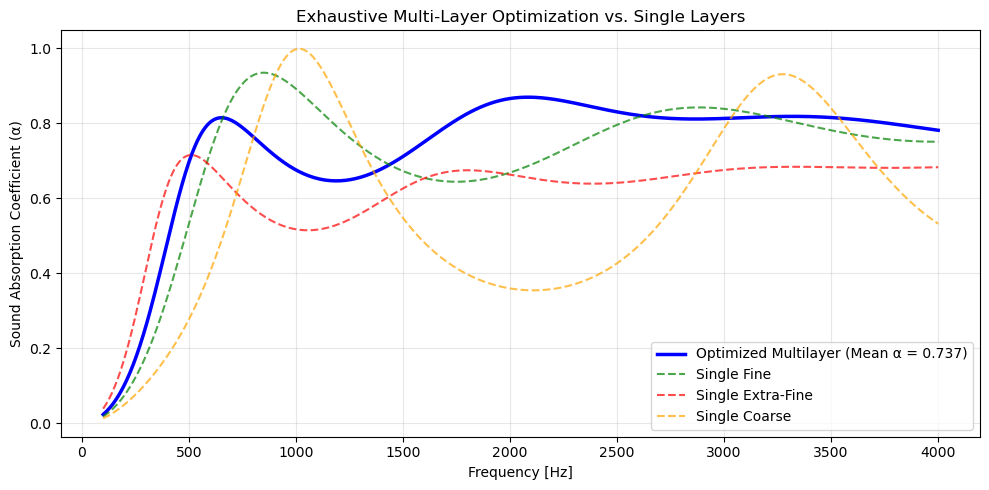

In [27]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

# =================================================================
# 1. CORE PHYSICS (VECTORIZED JCA & TRANSFER MATRIX METHOD)
# =================================================================
# Material Database (From Paper 1, Table 7)
MATERIALS = {
    1: {
        'name': 'Coarse',
        'phi': 0.41,
        'sigma': 5377,
        'alpha': 1.94,
        'L': 211e-6,
        'Lp': 221e-6,
    },
    2: {
        'name': 'Medium',
        'phi': 0.45,
        'sigma': 14811,
        'alpha': 1.62,
        'L': 86e-6,
        'Lp': 102e-6,
    },
    3: {
        'name': 'Fine',
        'phi': 0.54,
        'sigma': 19934,
        'alpha': 1.63,
        'L': 71e-6,
        'Lp': 85e-6,
    },
    4: {
        'name': 'Extra-Fine',
        'phi': 0.57,
        'sigma': 41344,
        'alpha': 2.50,
        'L': 38e-6,
        'Lp': 47e-6,
    },
}


def jca_properties_vec(f_vec, phi, sigma, alpha_inf, Lambda, Lambda_prime):
  """Evaluates Johnson-Champoux-Allard complex properties across all frequencies simultaneously."""
  omega = 2 * np.pi * f_vec
  rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5

  rho_e = (alpha_inf * rho_0 / phi) * (
      1
      + (sigma * phi)
      / (1j * omega * rho_0 * alpha_inf)
      * np.sqrt(
          1
          + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega)
          / (sigma**2 * Lambda**2 * phi**2)
      )
  )
  K_e = (gamma * P_0 / phi) / (
      gamma
      - (gamma - 1)
      / (
          1
          + (8 * eta)
          / (1j * omega * Pr * rho_0 * Lambda_prime**2)
          * np.sqrt(
              1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta)
          )
      )
  )

  Zc = np.sqrt(rho_e * K_e)
  k = omega * np.sqrt(rho_e / K_e)
  return Zc, k


def calculate_absorption_vectorized(
    thicknesses, material_indices, freq_range, Z0=413.5
):
  """Calculates sound absorption spectrum via TMM using NumPy matrix multiplication across frequencies."""
  num_freqs = len(freq_range)

  # Initialize transfer matrices [num_freqs, 2, 2] as identity matrices
  T_total = np.zeros((num_freqs, 2, 2), dtype=complex)
  T_total[:, 0, 0] = 1.0
  T_total[:, 1, 1] = 1.0

  for idx, d in zip(material_indices, thicknesses):
    p = MATERIALS[idx]
    Zc, k = jca_properties_vec(
        freq_range, p['phi'], p['sigma'], p['alpha'], p['L'], p['Lp']
    )

    cos_kd = np.cos(k * d)
    sin_kd = np.sin(k * d)

    T_layer = np.zeros((num_freqs, 2, 2), dtype=complex)
    T_layer[:, 0, 0] = cos_kd
    T_layer[:, 0, 1] = 1j * Zc * sin_kd
    T_layer[:, 1, 0] = (1j / Zc) * sin_kd
    T_layer[:, 1, 1] = cos_kd

    # Batch matrix multiplication: T_total = T_total @ T_layer
    T_total = np.einsum('nij,njk->nik', T_total, T_layer)

  Zs = T_total[:, 0, 0] / T_total[:, 1, 0]
  R = (Zs - Z0) / (Zs + Z0)
  return 1.0 - np.abs(R) ** 2


# =================================================================
# 2. HYBRID OPTIMIZATION PIPELINE WITH ITERATION LOGGING
# =================================================================
NUM_LAYERS = 4
TOTAL_THICKNESS = 0.05  # 50 mm total sample thickness
FREQS = np.linspace(100, 4000, 500)
MIN_THICKNESS = 0.003  # 3 mm minimum constraint per layer

# Generate all 256 possible discrete material permutations (4^4)
all_permutations = list(itertools.product([1, 2, 3, 4], repeat=NUM_LAYERS))

best_global_alpha = -1.0
best_global_config = None
best_global_thicknesses = None

bounds = [(MIN_THICKNESS, TOTAL_THICKNESS)] * NUM_LAYERS
constraints = {'type': 'eq', 'fun': lambda d: np.sum(d) - TOTAL_THICKNESS}
initial_thicknesses = np.ones(NUM_LAYERS) * (TOTAL_THICKNESS / NUM_LAYERS)

# Tracker variable used across the optimization loop
step_counter = 0

print(
    f'Evaluating all {len(all_permutations)} configurations and logging SLSQP thickness updates...\n'
)

for perm_idx, perm in enumerate(all_permutations, start=1):
  layer_names = [MATERIALS[idx]['name'] for idx in perm]
  step_counter = 0  # Reset step counter for every new material permutation

  print(f'=== Permutation {perm_idx}/{len(all_permutations)}: {layer_names} ===')

  def sub_objective(d):
    alpha = calculate_absorption_vectorized(d, perm, FREQS)
    return 1.0 - np.mean(alpha)

  # Callback function executed at each continuous optimization step
  def log_iteration(d):
    global step_counter
    step_counter += 1
    alpha = calculate_absorption_vectorized(d, perm, FREQS)
    mean_alpha = np.mean(alpha)
    thk_str = ', '.join([f'{val * 1000:.2f}' for val in d])
    print(
        f'  [Step {step_counter:02d}] Order: {layer_names} | Thicknesses'
        f' [mm]: [{thk_str}] | Mean Alpha: {mean_alpha:.4f}'
    )

  res = minimize(
      sub_objective,
      initial_thicknesses,
      method='SLSQP',
      bounds=bounds,
      constraints=constraints,
      callback=log_iteration,
      options={'ftol': 1e-5, 'maxiter': 100},
  )

  mean_alpha = 1.0 - res.fun
  print(
      f'  -> Final for {layer_names}: Mean Alpha = {mean_alpha:.4f},'
      f' Thicknesses [mm] = {np.round(res.x * 1000, 2)}\n'
  )

  if mean_alpha > best_global_alpha:
    best_global_alpha = mean_alpha
    best_global_config = perm
    best_global_thicknesses = res.x

# =================================================================
# 3. RESULTS & PLOTTING
# =================================================================
opt_names = [MATERIALS[idx]['name'] for idx in best_global_config]
opt_alpha = calculate_absorption_vectorized(
    best_global_thicknesses, best_global_config, FREQS
)

# Reference Single Layer Spectra (50 mm each)
ref_medium = calculate_absorption_vectorized([TOTAL_THICKNESS], [2], FREQS)
ref_fine = calculate_absorption_vectorized([TOTAL_THICKNESS], [3], FREQS)
ref_xfine = calculate_absorption_vectorized([TOTAL_THICKNESS], [4], FREQS)
ref_coarse = calculate_absorption_vectorized([TOTAL_THICKNESS], [1], FREQS)

print('=' * 60)
print('BEST GLOBAL OPTIMIZED DESIGN')
print('=' * 60)
print(f'Optimal Layer Order (Front -> Back): {opt_names}')
print(
    'Optimal Thicknesses (mm):          '
    f' {np.round(best_global_thicknesses * 1000, 2)}'
)
print(f'Mean Absorption Coefficient (Opt):   {best_global_alpha:.4f}')
print(f'Mean Absorption (Single Medium):    {np.mean(ref_medium):.4f}')
print(f'Mean Absorption (Single Fine):      {np.mean(ref_fine):.4f}')
print(f'Mean Absorption (Single Extra-Fine): {np.mean(ref_xfine):.4f}')
print(f'Mean Absorption (Single Coarse):    {np.mean(ref_coarse):.4f}')
print('=' * 60)

# Visualizing absorption spectrum
plt.figure(figsize=(10, 5))
plt.plot(
    FREQS,
    opt_alpha,
    color='blue',
    linewidth=2.5,
    label=f'Optimized Multilayer (Mean α = {best_global_alpha:.3f})',
)
plt.plot(
    FREQS,
    ref_fine,
    color='green',
    linestyle='--',
    alpha=0.7,
    label='Single Fine',
)
plt.plot(
    FREQS,
    ref_xfine,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Single Extra-Fine',
)
plt.plot(
    FREQS,
    ref_coarse,
    color='orange',
    linestyle='--',
    alpha=0.7,
    label='Single Coarse',
)
plt.title('Exhaustive Multi-Layer Optimization vs. Single Layers')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Sound Absorption Coefficient (α)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Generated 65536 total combinations, filtered down to 3876 impedance-matched gradient sequences.
Running SLSQP Optimization to find the optimal flattened profile...

 Improvement Found [1/3876]:
   Layers      : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S0']
   Thicknesses : [12.5 12.5 12.5 12.5] mm
   Mean Alpha  : 0.5752 | Ripple Std (f>800Hz) : 0.2107

 Improvement Found [2/3876]:
   Layers      : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S1']
   Thicknesses : [ 6.42  6.42  6.42 30.75] mm
   Mean Alpha  : 0.5844 | Ripple Std (f>800Hz) : 0.2012

 Improvement Found [3/3876]:
   Layers      : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S2']
   Thicknesses : [ 6.55  6.55  6.55 30.36] mm
   Mean Alpha  : 0.5970 | Ripple Std (f>800Hz) : 0.1866

 Improvement Found [4/3876]:
   Layers      : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S3']
   Thicknesses : [ 6.37  6.37  6.37 30.89] mm
   Mean Alpha  : 0.6110 | Ripple Std (f>800Hz) : 0.1689

 Improvement Found [5/3876]:
  

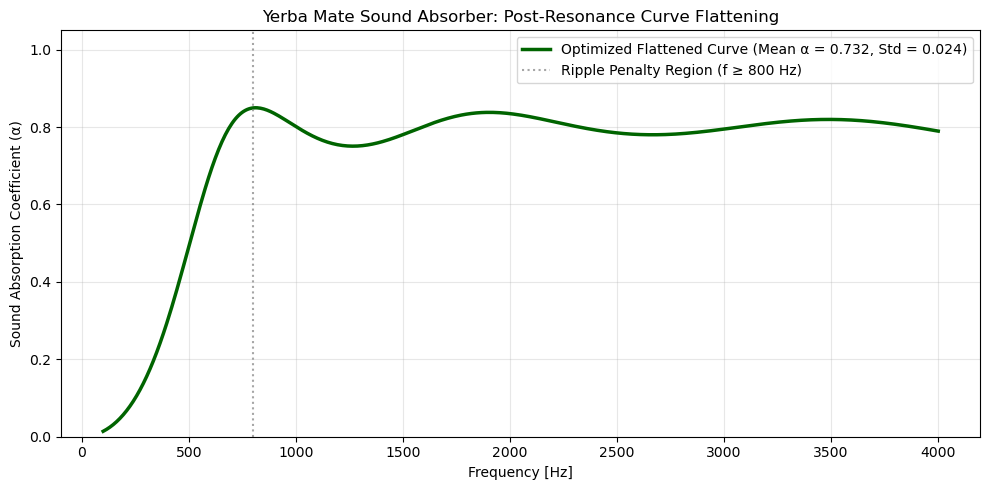

In [30]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

# =================================================================
# 1. EXPANDED MATERIAL DATABASE (Granulometry x Compaction States)
# =================================================================
# Update these parameters with the exact values from your Paper 1 Table
MATERIAL_DATABASE = {
    # COARSE (Granulometry 1)
    (1, 'S0'): {
        'name': 'Coarse-S0',
        'phi': 0.41,
        'sigma': 5377,
        'alpha': 1.94,
        'L': 211e-6,
        'Lp': 221e-6,
    },
    (1, 'S1'): {
        'name': 'Coarse-S1',
        'phi': 0.39,
        'sigma': 7200,
        'alpha': 1.98,
        'L': 195e-6,
        'Lp': 210e-6,
    },
    (1, 'S2'): {
        'name': 'Coarse-S2',
        'phi': 0.36,
        'sigma': 9800,
        'alpha': 2.05,
        'L': 175e-6,
        'Lp': 190e-6,
    },
    (1, 'S3'): {
        'name': 'Coarse-S3',
        'phi': 0.33,
        'sigma': 13500,
        'alpha': 2.12,
        'L': 150e-6,
        'Lp': 170e-6,
    },
    # MEDIUM (Granulometry 2)
    (2, 'S0'): {
        'name': 'Medium-S0',
        'phi': 0.45,
        'sigma': 14811,
        'alpha': 1.62,
        'L': 86e-6,
        'Lp': 102e-6,
    },
    (2, 'S1'): {
        'name': 'Medium-S1',
        'phi': 0.42,
        'sigma': 18500,
        'alpha': 1.68,
        'L': 78e-6,
        'Lp': 92e-6,
    },
    (2, 'S2'): {
        'name': 'Medium-S2',
        'phi': 0.39,
        'sigma': 23000,
        'alpha': 1.74,
        'L': 70e-6,
        'Lp': 83e-6,
    },
    (2, 'S3'): {
        'name': 'Medium-S3',
        'phi': 0.35,
        'sigma': 29500,
        'alpha': 1.82,
        'L': 61e-6,
        'Lp': 74e-6,
    },
    # FINE (Granulometry 3)
    (3, 'S0'): {
        'name': 'Fine-S0',
        'phi': 0.54,
        'sigma': 19934,
        'alpha': 1.63,
        'L': 71e-6,
        'Lp': 85e-6,
    },
    (3, 'S1'): {
        'name': 'Fine-S1',
        'phi': 0.50,
        'sigma': 26000,
        'alpha': 1.71,
        'L': 62e-6,
        'Lp': 75e-6,
    },
    (3, 'S2'): {
        'name': 'Fine-S2',
        'phi': 0.46,
        'sigma': 33500,
        'alpha': 1.80,
        'L': 53e-6,
        'Lp': 66e-6,
    },
    (3, 'S3'): {
        'name': 'Fine-S3',
        'phi': 0.42,
        'sigma': 42000,
        'alpha': 1.90,
        'L': 45e-6,
        'Lp': 57e-6,
    },
    # EXTRA-FINE (Granulometry 4)
    (4, 'S0'): {
        'name': 'ExFine-S0',
        'phi': 0.57,
        'sigma': 41344,
        'alpha': 2.50,
        'L': 38e-6,
        'Lp': 47e-6,
    },
    (4, 'S1'): {
        'name': 'ExFine-S1',
        'phi': 0.52,
        'sigma': 52000,
        'alpha': 2.62,
        'L': 32e-6,
        'Lp': 40e-6,
    },
    (4, 'S2'): {
        'name': 'ExFine-S2',
        'phi': 0.47,
        'sigma': 65000,
        'alpha': 2.75,
        'L': 27e-6,
        'Lp': 34e-6,
    },
    (4, 'S3'): {
        'name': 'ExFine-S3',
        'phi': 0.42,
        'sigma': 81000,
        'alpha': 2.90,
        'L': 22e-6,
        'Lp': 28e-6,
    },
}

MATERIAL_KEYS = list(MATERIAL_DATABASE.keys())


# =================================================================
# 2. CORE PHYSICS (VECTORIZED JCA & TMM)
# =================================================================
def jca_properties_vec(f_vec, phi, sigma, alpha_inf, Lambda, Lambda_prime):
  omega = 2 * np.pi * f_vec
  rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5

  rho_e = (alpha_inf * rho_0 / phi) * (
      1
      + (sigma * phi)
      / (1j * omega * rho_0 * alpha_inf)
      * np.sqrt(
          1
          + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega)
          / (sigma**2 * Lambda**2 * phi**2)
      )
  )
  K_e = (gamma * P_0 / phi) / (
      gamma
      - (gamma - 1)
      / (
          1
          + (8 * eta)
          / (1j * omega * Pr * rho_0 * Lambda_prime**2)
          * np.sqrt(
              1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta)
          )
      )
  )

  Zc = np.sqrt(rho_e * K_e)
  k = omega * np.sqrt(rho_e / K_e)
  return Zc, k


def calculate_absorption_vectorized(
    thicknesses, selected_material_keys, freq_range, Z0=413.5
):
  num_freqs = len(freq_range)

  T_total = np.zeros((num_freqs, 2, 2), dtype=complex)
  T_total[:, 0, 0] = 1.0
  T_total[:, 1, 1] = 1.0

  for mat_key, d in zip(selected_material_keys, thicknesses):
    p = MATERIAL_DATABASE[mat_key]
    Zc, k = jca_properties_vec(
        freq_range, p['phi'], p['sigma'], p['alpha'], p['L'], p['Lp']
    )

    cos_kd = np.cos(k * d)
    sin_kd = np.sin(k * d)

    T_layer = np.zeros((num_freqs, 2, 2), dtype=complex)
    T_layer[:, 0, 0] = cos_kd
    T_layer[:, 0, 1] = 1j * Zc * sin_kd
    T_layer[:, 1, 0] = (1j / Zc) * sin_kd
    T_layer[:, 1, 1] = cos_kd

    T_total = np.einsum('nij,njk->nik', T_total, T_layer)

  Zs = T_total[:, 0, 0] / T_total[:, 1, 0]
  R = (Zs - Z0) / (Zs + Z0)
  return 1.0 - np.abs(R) ** 2


# =================================================================
# 3. FLATNESS COST FUNCTION
# =================================================================
def calculate_flatness_cost(
    thicknesses, material_keys, freq_range, beta=1.0, f_threshold=800.0
):
  """Evaluates mean absorption while penalizing variance (ripples) above f_threshold."""
  alpha = calculate_absorption_vectorized(thicknesses, material_keys, freq_range)

  mask_post = freq_range >= f_threshold
  alpha_post = alpha[mask_post]

  mean_alpha_total = np.mean(alpha)
  mean_alpha_post = np.mean(alpha_post)
  std_alpha_post = np.std(alpha_post)  # Ripple penalty term

  # Cost minimizes (1 - mean_alpha) while penalizing variance/ripples
  cost = (
      (1.0 - mean_alpha_total)
      + 0.5 * (1.0 - mean_alpha_post)
      + beta * std_alpha_post
  )
  return cost


# =================================================================
# 4. OPTIMIZATION PIPELINE
# =================================================================
NUM_LAYERS = 4
TOTAL_THICKNESS = 0.05  # 50 mm total
FREQS = np.linspace(100, 4000, 500)
MIN_THICKNESS = 0.003  # 3 mm minimum constraint per layer

all_combinations = list(itertools.product(MATERIAL_KEYS, repeat=NUM_LAYERS))

# Enforce monotonic flow-resistivity gradient: sigma1 <= sigma2 <= sigma3 <= sigma4
# This prevents interface reflections and eliminates post-peak ripples
gradient_combinations = []
for comb in all_combinations:
  sigmas = [MATERIAL_DATABASE[k]['sigma'] for k in comb]
  if sigmas == sorted(sigmas):
    gradient_combinations.append(comb)

print(
    f'Generated {len(all_combinations)} total combinations, filtered down to'
    f' {len(gradient_combinations)} impedance-matched gradient sequences.'
)

best_flatness_cost = 1e6
best_flat_config = None
best_flat_thicknesses = None

bounds = [(MIN_THICKNESS, TOTAL_THICKNESS)] * NUM_LAYERS
constraints = {'type': 'eq', 'fun': lambda d: np.sum(d) - TOTAL_THICKNESS}
initial_thicknesses = np.ones(NUM_LAYERS) * (TOTAL_THICKNESS / NUM_LAYERS)

print('Running SLSQP Optimization to find the optimal flattened profile...\n')

for comb_idx, comb in enumerate(gradient_combinations, start=1):

  def sub_objective(d):
    return calculate_flatness_cost(d, comb, FREQS, beta=1.2, f_threshold=800.0)

  res = minimize(
      sub_objective,
      initial_thicknesses,
      method='SLSQP',
      bounds=bounds,
      constraints=constraints,
      options={'ftol': 1e-4, 'maxiter': 50},
  )

  if res.fun < best_flatness_cost:
    best_flatness_cost = res.fun
    best_flat_config = comb
    best_flat_thicknesses = res.x

    layer_names = [MATERIAL_DATABASE[k]['name'] for k in comb]
    alpha_temp = calculate_absorption_vectorized(res.x, comb, FREQS)
    std_temp = np.std(alpha_temp[FREQS >= 800])

    print(f' Improvement Found [{comb_idx}/{len(gradient_combinations)}]:')
    print(f'   Layers      : {layer_names}')
    print(
        '   Thicknesses :'
        f' {np.round(best_flat_thicknesses * 1000, 2)} mm'
    )
    print(
        f'   Mean Alpha  : {np.mean(alpha_temp):.4f} | Ripple Std (f>800Hz) :'
        f' {std_temp:.4f}\n'
    )

# =================================================================
# 5. FINAL RESULTS & PLOTTING
# =================================================================
flat_names = [MATERIAL_DATABASE[k]['name'] for k in best_flat_config]
flat_alpha = calculate_absorption_vectorized(
    best_flat_thicknesses, best_flat_config, FREQS
)
post_std = np.std(flat_alpha[FREQS >= 800])

print('=' * 65)
print('BEST FLATTENED IMPEDANCE-GRADIENT MULTILAYER DESIGN')
print('=' * 65)
print(f'Optimal Layer Order (Front -> Back): {flat_names}')
print(
    'Optimal Thicknesses (mm):          '
    f' {np.round(best_flat_thicknesses * 1000, 2)}'
)
print(f'Mean Absorption (100 - 4000 Hz):     {np.mean(flat_alpha):.4f}')
print(f'Post-Resonance Ripple Std (f>800Hz):  {post_std:.4f}')
print('=' * 65)

plt.figure(figsize=(10, 5))
plt.plot(
    FREQS,
    flat_alpha,
    color='darkgreen',
    linewidth=2.5,
    label=(
        f'Optimized Flattened Curve (Mean α = {np.mean(flat_alpha):.3f},'
        f' Std = {post_std:.3f})'
    ),
)
plt.axvline(
    x=800,
    color='gray',
    linestyle=':',
    alpha=0.7,
    label='Ripple Penalty Region (f ≥ 800 Hz)',
)
plt.title('Yerba Mate Sound Absorber: Post-Resonance Curve Flattening')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Sound Absorption Coefficient (α)')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Generated 1048576 total combinations, filtered down to 15504 impedance-matched gradient sequences.
Running SLSQP Optimization...

 Improvement Found [1/15504]:
   Layers      : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S0']
   Thicknesses : [10. 10. 10. 10. 10.] mm
   Mean Alpha  : 0.5752 | Ripple Std (f>800Hz) : 0.2107

 Improvement Found [2/15504]:
   Layers      : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S1']
   Thicknesses : [ 4.81  4.81  4.81  4.81 30.74] mm
   Mean Alpha  : 0.5844 | Ripple Std (f>800Hz) : 0.2012

 Improvement Found [3/15504]:
   Layers      : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S2']
   Thicknesses : [ 4.91  4.91  4.91  4.91 30.37] mm
   Mean Alpha  : 0.5970 | Ripple Std (f>800Hz) : 0.1866

 Improvement Found [4/15504]:
   Layers      : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S3']
   Thicknesses : [ 4.8   4.8   4.8   4.8  30.78] mm
   Mean Alpha  : 0.6110 | Ripple Std (f>800Hz) : 

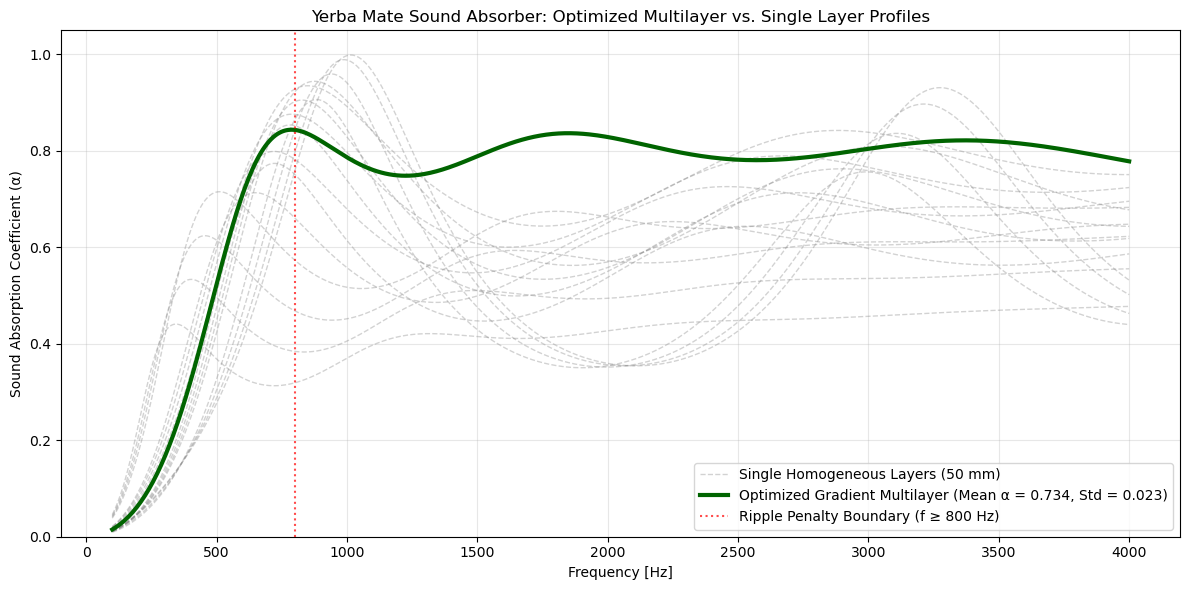

In [33]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

# =================================================================
# 1. EXPANDED MATERIAL DATABASE (Granulometry x Compaction States)
# =================================================================
MATERIAL_DATABASE = {
    # COARSE (Granulometry 1)
    (1, 'S0'): {
        'name': 'Coarse-S0',
        'phi': 0.41,
        'sigma': 5377,
        'alpha': 1.94,
        'L': 211e-6,
        'Lp': 221e-6,
    },
    (1, 'S1'): {
        'name': 'Coarse-S1',
        'phi': 0.39,
        'sigma': 7200,
        'alpha': 1.98,
        'L': 195e-6,
        'Lp': 210e-6,
    },
    (1, 'S2'): {
        'name': 'Coarse-S2',
        'phi': 0.36,
        'sigma': 9800,
        'alpha': 2.05,
        'L': 175e-6,
        'Lp': 190e-6,
    },
    (1, 'S3'): {
        'name': 'Coarse-S3',
        'phi': 0.33,
        'sigma': 13500,
        'alpha': 2.12,
        'L': 150e-6,
        'Lp': 170e-6,
    },
    # MEDIUM (Granulometry 2)
    (2, 'S0'): {
        'name': 'Medium-S0',
        'phi': 0.45,
        'sigma': 14811,
        'alpha': 1.62,
        'L': 86e-6,
        'Lp': 102e-6,
    },
    (2, 'S1'): {
        'name': 'Medium-S1',
        'phi': 0.42,
        'sigma': 18500,
        'alpha': 1.68,
        'L': 78e-6,
        'Lp': 92e-6,
    },
    (2, 'S2'): {
        'name': 'Medium-S2',
        'phi': 0.39,
        'sigma': 23000,
        'alpha': 1.74,
        'L': 70e-6,
        'Lp': 83e-6,
    },
    (2, 'S3'): {
        'name': 'Medium-S3',
        'phi': 0.35,
        'sigma': 29500,
        'alpha': 1.82,
        'L': 61e-6,
        'Lp': 74e-6,
    },
    # FINE (Granulometry 3)
    (3, 'S0'): {
        'name': 'Fine-S0',
        'phi': 0.54,
        'sigma': 19934,
        'alpha': 1.63,
        'L': 71e-6,
        'Lp': 85e-6,
    },
    (3, 'S1'): {
        'name': 'Fine-S1',
        'phi': 0.50,
        'sigma': 26000,
        'alpha': 1.71,
        'L': 62e-6,
        'Lp': 75e-6,
    },
    (3, 'S2'): {
        'name': 'Fine-S2',
        'phi': 0.46,
        'sigma': 33500,
        'alpha': 1.80,
        'L': 53e-6,
        'Lp': 66e-6,
    },
    (3, 'S3'): {
        'name': 'Fine-S3',
        'phi': 0.42,
        'sigma': 42000,
        'alpha': 1.90,
        'L': 45e-6,
        'Lp': 57e-6,
    },
    # EXTRA-FINE (Granulometry 4)
    (4, 'S0'): {
        'name': 'ExFine-S0',
        'phi': 0.57,
        'sigma': 41344,
        'alpha': 2.50,
        'L': 38e-6,
        'Lp': 47e-6,
    },
    (4, 'S1'): {
        'name': 'ExFine-S1',
        'phi': 0.52,
        'sigma': 52000,
        'alpha': 2.62,
        'L': 32e-6,
        'Lp': 40e-6,
    },
    (4, 'S2'): {
        'name': 'ExFine-S2',
        'phi': 0.47,
        'sigma': 65000,
        'alpha': 2.75,
        'L': 27e-6,
        'Lp': 34e-6,
    },
    (4, 'S3'): {
        'name': 'ExFine-S3',
        'phi': 0.42,
        'sigma': 81000,
        'alpha': 2.90,
        'L': 22e-6,
        'Lp': 28e-6,
    },
}

MATERIAL_KEYS = list(MATERIAL_DATABASE.keys())


# =================================================================
# 2. CORE PHYSICS (VECTORIZED JCA & TMM)
# =================================================================
def jca_properties_vec(f_vec, phi, sigma, alpha_inf, Lambda, Lambda_prime):
  omega = 2 * np.pi * f_vec
  rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5

  rho_e = (alpha_inf * rho_0 / phi) * (
      1
      + (sigma * phi)
      / (1j * omega * rho_0 * alpha_inf)
      * np.sqrt(
          1
          + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega)
          / (sigma**2 * Lambda**2 * phi**2)
      )
  )
  K_e = (gamma * P_0 / phi) / (
      gamma
      - (gamma - 1)
      / (
          1
          + (8 * eta)
          / (1j * omega * Pr * rho_0 * Lambda_prime**2)
          * np.sqrt(
              1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta)
          )
      )
  )

  Zc = np.sqrt(rho_e * K_e)
  k = omega * np.sqrt(rho_e / K_e)
  return Zc, k


def calculate_absorption_vectorized(
    thicknesses, selected_material_keys, freq_range, Z0=413.5
):
  num_freqs = len(freq_range)

  T_total = np.zeros((num_freqs, 2, 2), dtype=complex)
  T_total[:, 0, 0] = 1.0
  T_total[:, 1, 1] = 1.0

  for mat_key, d in zip(selected_material_keys, thicknesses):
    p = MATERIAL_DATABASE[mat_key]
    Zc, k = jca_properties_vec(
        freq_range, p['phi'], p['sigma'], p['alpha'], p['L'], p['Lp']
    )

    cos_kd = np.cos(k * d)
    sin_kd = np.sin(k * d)

    T_layer = np.zeros((num_freqs, 2, 2), dtype=complex)
    T_layer[:, 0, 0] = cos_kd
    T_layer[:, 0, 1] = 1j * Zc * sin_kd
    T_layer[:, 1, 0] = (1j / Zc) * sin_kd
    T_layer[:, 1, 1] = cos_kd

    T_total = np.einsum('nij,njk->nik', T_total, T_layer)

  Zs = T_total[:, 0, 0] / T_total[:, 1, 0]
  R = (Zs - Z0) / (Zs + Z0)
  return 1.0 - np.abs(R) ** 2


# =================================================================
# 3. FLATNESS COST FUNCTION
# =================================================================
def calculate_flatness_cost(
    thicknesses, material_keys, freq_range, beta=1.2, f_threshold=800.0
):
  alpha = calculate_absorption_vectorized(thicknesses, material_keys, freq_range)

  mask_post = freq_range >= f_threshold
  alpha_post = alpha[mask_post]

  mean_alpha_total = np.mean(alpha)
  mean_alpha_post = np.mean(alpha_post)
  std_alpha_post = np.std(alpha_post)

  cost = (
      (1.0 - mean_alpha_total)
      + 0.5 * (1.0 - mean_alpha_post)
      + beta * std_alpha_post
  )
  return cost


# =================================================================
# 4. OPTIMIZATION PIPELINE
# =================================================================
NUM_LAYERS = 5
TOTAL_THICKNESS = 0.05  # 50 mm total
FREQS = np.linspace(100, 4000, 500)
MIN_THICKNESS = 0.003  # 3 mm minimum constraint per layer

all_combinations = list(itertools.product(MATERIAL_KEYS, repeat=NUM_LAYERS))

# Filter to enforce monotonic flow-resistivity gradient: sigma1 <= sigma2 <= sigma3 <= sigma4
gradient_combinations = []
for comb in all_combinations:
  sigmas = [MATERIAL_DATABASE[k]['sigma'] for k in comb]
  if sigmas == sorted(sigmas):
    gradient_combinations.append(comb)

print(
    f'Generated {len(all_combinations)} total combinations, filtered down to'
    f' {len(gradient_combinations)} impedance-matched gradient sequences.'
)

best_flatness_cost = 1e6
best_flat_config = None
best_flat_thicknesses = None

bounds = [(MIN_THICKNESS, TOTAL_THICKNESS)] * NUM_LAYERS
constraints = {'type': 'eq', 'fun': lambda d: np.sum(d) - TOTAL_THICKNESS}
initial_thicknesses = np.ones(NUM_LAYERS) * (TOTAL_THICKNESS / NUM_LAYERS)

print('Running SLSQP Optimization...\n')

for comb_idx, comb in enumerate(gradient_combinations, start=1):

  def sub_objective(d):
    return calculate_flatness_cost(d, comb, FREQS, beta=1.2, f_threshold=800.0)

  res = minimize(
      sub_objective,
      initial_thicknesses,
      method='SLSQP',
      bounds=bounds,
      constraints=constraints,
      options={'ftol': 1e-4, 'maxiter': 50},
  )

  if res.fun < best_flatness_cost:
    best_flatness_cost = res.fun
    best_flat_config = comb
    best_flat_thicknesses = res.x

    layer_names = [MATERIAL_DATABASE[k]['name'] for k in comb]
    alpha_temp = calculate_absorption_vectorized(res.x, comb, FREQS)
    std_temp = np.std(alpha_temp[FREQS >= 800])

    print(f' Improvement Found [{comb_idx}/{len(gradient_combinations)}]:')
    print(f'   Layers      : {layer_names}')
    print(
        '   Thicknesses :'
        f' {np.round(best_flat_thicknesses * 1000, 2)} mm'
    )
    print(
        f'   Mean Alpha  : {np.mean(alpha_temp):.4f} | Ripple Std (f>800Hz) :'
        f' {std_temp:.4f}\n'
    )

# =================================================================
# 5. COMPUTE SINGLE LAYER CURVES FOR COMPARISON
# =================================================================
single_layer_curves = {}
for k in MATERIAL_KEYS:
  # Compute 50mm single layer response
  alpha_single = calculate_absorption_vectorized(
      [TOTAL_THICKNESS], [k], FREQS
  )
  single_layer_curves[k] = alpha_single

# =================================================================
# 6. FINAL RESULTS & COMPARATIVE PLOTTING
# =================================================================
flat_names = [MATERIAL_DATABASE[k]['name'] for k in best_flat_config]
flat_alpha = calculate_absorption_vectorized(
    best_flat_thicknesses, best_flat_config, FREQS
)
post_std = np.std(flat_alpha[FREQS >= 800])

print('=' * 65)
print('BEST FLATTENED IMPEDANCE-GRADIENT MULTILAYER DESIGN')
print('=' * 65)
print(f'Optimal Layer Order (Front -> Back): {flat_names}')
print(
    'Optimal Thicknesses (mm):          '
    f' {np.round(best_flat_thicknesses * 1000, 2)}'
)
print(f'Mean Absorption (100 - 4000 Hz):     {np.mean(flat_alpha):.4f}')
print(f'Post-Resonance Ripple Std (f>800Hz):  {post_std:.4f}')
print('=' * 65)

plt.figure(figsize=(12, 6))

# Plot single layers in thin gray lines to show individual resonance ripples
first_label = True
for k, alpha_s in single_layer_curves.items():
  label_txt = 'Single Homogeneous Layers (50 mm)' if first_label else None
  plt.plot(
      FREQS,
      alpha_s,
      color='gray',
      linestyle='--',
      alpha=0.35,
      linewidth=1.0,
      label=label_txt,
  )
  first_label = False

# Plot optimized flattened multilayer
plt.plot(
    FREQS,
    flat_alpha,
    color='darkgreen',
    linewidth=3.0,
    label=(
        f'Optimized Gradient Multilayer (Mean α = {np.mean(flat_alpha):.3f},'
        f' Std = {post_std:.3f})'
    ),
)

plt.axvline(
    x=800,
    color='red',
    linestyle=':',
    alpha=0.7,
    label='Ripple Penalty Boundary (f ≥ 800 Hz)',
)
plt.title(
    'Yerba Mate Sound Absorber: Optimized Multilayer vs. Single Layer Profiles'
)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Sound Absorption Coefficient (α)')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
import itertools
import matplotlib.pyplot as plt
import numpy as np

# =================================================================
# 1. EXPANDED MATERIAL DATABASE (Granulometry x Compaction States)
# =================================================================
MATERIAL_DATABASE = {
    # COARSE (Granulometry 1)
    (1, 'S0'): {
        'name': 'Coarse-S0',
        'phi': 0.41,
        'sigma': 5377,
        'alpha': 1.94,
        'L': 211e-6,
        'Lp': 221e-6,
    },
    (1, 'S1'): {
        'name': 'Coarse-S1',
        'phi': 0.39,
        'sigma': 7200,
        'alpha': 1.98,
        'L': 195e-6,
        'Lp': 210e-6,
    },
    (1, 'S2'): {
        'name': 'Coarse-S2',
        'phi': 0.36,
        'sigma': 9800,
        'alpha': 2.05,
        'L': 175e-6,
        'Lp': 190e-6,
    },
    (1, 'S3'): {
        'name': 'Coarse-S3',
        'phi': 0.33,
        'sigma': 13500,
        'alpha': 2.12,
        'L': 150e-6,
        'Lp': 170e-6,
    },
    # MEDIUM (Granulometry 2)
    (2, 'S0'): {
        'name': 'Medium-S0',
        'phi': 0.45,
        'sigma': 14811,
        'alpha': 1.62,
        'L': 86e-6,
        'Lp': 102e-6,
    },
    (2, 'S1'): {
        'name': 'Medium-S1',
        'phi': 0.42,
        'sigma': 18500,
        'alpha': 1.68,
        'L': 78e-6,
        'Lp': 92e-6,
    },
    (2, 'S2'): {
        'name': 'Medium-S2',
        'phi': 0.39,
        'sigma': 23000,
        'alpha': 1.74,
        'L': 70e-6,
        'Lp': 83e-6,
    },
    (2, 'S3'): {
        'name': 'Medium-S3',
        'phi': 0.35,
        'sigma': 29500,
        'alpha': 1.82,
        'L': 61e-6,
        'Lp': 74e-6,
    },
    # FINE (Granulometry 3)
    (3, 'S0'): {
        'name': 'Fine-S0',
        'phi': 0.54,
        'sigma': 19934,
        'alpha': 1.63,
        'L': 71e-6,
        'Lp': 85e-6,
    },
    (3, 'S1'): {
        'name': 'Fine-S1',
        'phi': 0.50,
        'sigma': 26000,
        'alpha': 1.71,
        'L': 62e-6,
        'Lp': 75e-6,
    },
    (3, 'S2'): {
        'name': 'Fine-S2',
        'phi': 0.46,
        'sigma': 33500,
        'alpha': 1.80,
        'L': 53e-6,
        'Lp': 66e-6,
    },
    (3, 'S3'): {
        'name': 'Fine-S3',
        'phi': 0.42,
        'sigma': 42000,
        'alpha': 1.90,
        'L': 45e-6,
        'Lp': 57e-6,
    },
    # EXTRA-FINE (Granulometry 4)
    (4, 'S0'): {
        'name': 'ExFine-S0',
        'phi': 0.57,
        'sigma': 41344,
        'alpha': 2.50,
        'L': 38e-6,
        'Lp': 47e-6,
    },
    (4, 'S1'): {
        'name': 'ExFine-S1',
        'phi': 0.52,
        'sigma': 52000,
        'alpha': 2.62,
        'L': 32e-6,
        'Lp': 40e-6,
    },
    (4, 'S2'): {
        'name': 'ExFine-S2',
        'phi': 0.47,
        'sigma': 65000,
        'alpha': 2.75,
        'L': 27e-6,
        'Lp': 34e-6,
    },
    (4, 'S3'): {
        'name': 'ExFine-S3',
        'phi': 0.42,
        'sigma': 81000,
        'alpha': 2.90,
        'L': 22e-6,
        'Lp': 28e-6,
    },
}

MATERIAL_KEYS = list(MATERIAL_DATABASE.keys())


# =================================================================
# 2. CORE PHYSICS (VECTORIZED JCA & TMM)
# =================================================================
def jca_properties_vec(f_vec, phi, sigma, alpha_inf, Lambda, Lambda_prime):
  omega = 2 * np.pi * f_vec
  rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5

  rho_e = (alpha_inf * rho_0 / phi) * (
      1
      + (sigma * phi)
      / (1j * omega * rho_0 * alpha_inf)
      * np.sqrt(
          1
          + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega)
          / (sigma**2 * Lambda**2 * phi**2)
      )
  )
  K_e = (gamma * P_0 / phi) / (
      gamma
      - (gamma - 1)
      / (
          1
          + (8 * eta)
          / (1j * omega * Pr * rho_0 * Lambda_prime**2)
          * np.sqrt(
              1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta)
          )
      )
  )

  Zc = np.sqrt(rho_e * K_e)
  k = omega * np.sqrt(rho_e / K_e)
  return Zc, k


def calculate_absorption_vectorized(
    thicknesses_m, selected_material_keys, freq_range, Z0=413.5
):
  num_freqs = len(freq_range)

  T_total = np.zeros((num_freqs, 2, 2), dtype=complex)
  T_total[:, 0, 0] = 1.0
  T_total[:, 1, 1] = 1.0

  for mat_key, d in zip(selected_material_keys, thicknesses_m):
    p = MATERIAL_DATABASE[mat_key]
    Zc, k = jca_properties_vec(
        freq_range, p['phi'], p['sigma'], p['alpha'], p['L'], p['Lp']
    )

    cos_kd = np.cos(k * d)
    sin_kd = np.sin(k * d)

    T_layer = np.zeros((num_freqs, 2, 2), dtype=complex)
    T_layer[:, 0, 0] = cos_kd
    T_layer[:, 0, 1] = 1j * Zc * sin_kd
    T_layer[:, 1, 0] = (1j / Zc) * sin_kd
    T_layer[:, 1, 1] = cos_kd

    T_total = np.einsum('nij,njk->nik', T_total, T_layer)

  Zs = T_total[:, 0, 0] / T_total[:, 1, 0]
  R = (Zs - Z0) / (Zs + Z0)
  return 1.0 - np.abs(R) ** 2


# =================================================================
# 3. FLATNESS COST FUNCTION
# =================================================================
def calculate_flatness_cost(
    thicknesses_m, material_keys, freq_range, beta=1.2, f_threshold=800.0
):
  alpha = calculate_absorption_vectorized(
      thicknesses_m, material_keys, freq_range
  )

  mask_post = freq_range >= f_threshold
  alpha_post = alpha[mask_post]

  mean_alpha_total = np.mean(alpha)
  mean_alpha_post = np.mean(alpha_post)
  std_alpha_post = np.std(alpha_post)

  cost = (
      (1.0 - mean_alpha_total)
      + 0.5 * (1.0 - mean_alpha_post)
      + beta * std_alpha_post
  )
  return cost


# =================================================================
# 4. DISCRETE INTEGER MILLIMETER OPTIMIZATION
# =================================================================
NUM_LAYERS = 4
TOTAL_THICKNESS_MM = 50  # Total thickness in integer mm
MIN_THICKNESS_MM = 3  # Minimum thickness per layer in integer mm
FREQS = np.linspace(100, 4000, 500)


# Generate all valid combinations of 4 integer thicknesses (in mm) that sum to 50 mm
def generate_integer_thickness_partitions(
    total_mm, num_layers, min_mm, step_mm=1
):
  valid_partitions = []
  range_per_layer = range(min_mm, total_mm - min_mm * (num_layers - 1) + 1)
  for p in itertools.product(range_per_layer, repeat=num_layers):
    if sum(p) == total_mm:
      valid_partitions.append(p)
  return valid_partitions


thickness_candidates_mm = generate_integer_thickness_partitions(
    TOTAL_THICKNESS_MM, NUM_LAYERS, MIN_THICKNESS_MM
)
print(
    f'Generated {len(thickness_candidates_mm)} valid integer millimeter'
    f' thickness partitions (Sum = {TOTAL_THICKNESS_MM} mm).'
)

# Enforce monotonic flow-resistivity gradient: sigma1 <= sigma2 <= sigma3 <= sigma4
all_combinations = list(itertools.product(MATERIAL_KEYS, repeat=NUM_LAYERS))
gradient_combinations = []
for comb in all_combinations:
  sigmas = [MATERIAL_DATABASE[k]['sigma'] for k in comb]
  if sigmas == sorted(sigmas):
    gradient_combinations.append(comb)

print(
    f'Filtered material sequences to {len(gradient_combinations)}'
    ' gradient combinations.'
)

best_flatness_cost = 1e6
best_flat_config = None
best_flat_thicknesses_mm = None

print(
    'Running Discrete Integer Optimization over Material & Thickness'
    ' Space...\n'
)

# Search across material sequences and integer thickness distributions
for comb in gradient_combinations:
  for d_mm in thickness_candidates_mm:
    d_m = [x / 1000.0 for x in d_mm]  # convert mm to meters for physics calculation
    cost = calculate_flatness_cost(d_m, comb, FREQS, beta=1.2, f_threshold=800.0)

    if cost < best_flatness_cost:
      best_flatness_cost = cost
      best_flat_config = comb
      best_flat_thicknesses_mm = d_mm

      layer_names = [MATERIAL_DATABASE[k]['name'] for k in comb]
      alpha_temp = calculate_absorption_vectorized(d_m, comb, FREQS)
      std_temp = np.std(alpha_temp[FREQS >= 800])

      print(f' Improvement Found:')
      print(f'   Layers          : {layer_names}')
      print(f'   Thicknesses (mm): {list(best_flat_thicknesses_mm)} [Integer]')
      print(
          f'   Mean Alpha      : {np.mean(alpha_temp):.4f} | Ripple Std'
          f' (f>800Hz) : {std_temp:.4f}\n'
      )

# =================================================================
# 5. COMPUTE SINGLE LAYER CURVES FOR COMPARISON
# =================================================================
single_layer_curves = {}
for k in MATERIAL_KEYS:
  alpha_single = calculate_absorption_vectorized(
      [TOTAL_THICKNESS_MM / 1000.0], [k], FREQS
  )
  single_layer_curves[k] = alpha_single

# =================================================================
# 6. FINAL RESULTS & PLOTTING
# =================================================================
flat_names = [MATERIAL_DATABASE[k]['name'] for k in best_flat_config]
best_d_m = [x / 1000.0 for x in best_flat_thicknesses_mm]
flat_alpha = calculate_absorption_vectorized(best_d_m, best_flat_config, FREQS)
post_std = np.std(flat_alpha[FREQS >= 800])

print('=' * 65)
print('BEST FLATTENED IMPEDANCE-GRADIENT MULTILAYER DESIGN (INTEGER MM)')
print('=' * 65)
print(f'Optimal Layer Order (Front -> Back): {flat_names}')
print(f'Optimal Thicknesses (mm):          {list(best_flat_thicknesses_mm)}')
print(f'Total Thickness (mm):              {sum(best_flat_thicknesses_mm)}')
print(f'Mean Absorption (100 - 4000 Hz):     {np.mean(flat_alpha):.4f}')
print(f'Post-Resonance Ripple Std (f>800Hz):  {post_std:.4f}')
print('=' * 65)

plt.figure(figsize=(12, 6))

first_label = True
for k, alpha_s in single_layer_curves.items():
  label_txt = 'Single Homogeneous Layers (50 mm)' if first_label else None
  plt.plot(
      FREQS,
      alpha_s,
      color='gray',
      linestyle='--',
      alpha=0.35,
      linewidth=1.0,
      label=label_txt,
  )
  first_label = False

plt.plot(
    FREQS,
    flat_alpha,
    color='darkgreen',
    linewidth=3.0,
    label=(
        f'Optimized Integer Multilayer {list(best_flat_thicknesses_mm)} mm'
        f' (Mean α = {np.mean(flat_alpha):.3f}, Std = {post_std:.3f})'
    ),
)

plt.axvline(
    x=800,
    color='red',
    linestyle=':',
    alpha=0.7,
    label='Ripple Penalty Boundary (f ≥ 800 Hz)',
)
plt.title(
    'Yerba Mate Sound Absorber: Integer-Millimeter Multilayer vs. Single'
    ' Layers'
)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Sound Absorption Coefficient (α)')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Generated 10660 valid integer millimeter thickness partitions (Sum = 50 mm).
Filtered material sequences to 3876 gradient combinations.
Running Discrete Integer Optimization over Material & Thickness Space...

 Improvement Found:
   Layers          : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S0']
   Thicknesses (mm): [3, 3, 3, 41] [Integer]
   Mean Alpha      : 0.5752 | Ripple Std (f>800Hz) : 0.2107

 Improvement Found:
   Layers          : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S1']
   Thicknesses (mm): [3, 3, 3, 41] [Integer]
   Mean Alpha      : 0.5774 | Ripple Std (f>800Hz) : 0.2035

 Improvement Found:
   Layers          : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S1']
   Thicknesses (mm): [3, 3, 4, 40] [Integer]
   Mean Alpha      : 0.5789 | Ripple Std (f>800Hz) : 0.2035

 Improvement Found:
   Layers          : ['Coarse-S0', 'Coarse-S0', 'Coarse-S0', 'Coarse-S1']
   Thicknesses (mm): [3, 3, 5, 39] [Integer]
   Mean Alpha      : 0.5802 | Ripple Std (f>800Hz) 

KeyboardInterrupt: 

In [ ]:
import itertools
import matplotlib.pyplot as plt
import numpy as np

# =================================================================
# 1. EXPANDED MATERIAL DATABASE (Granulometry x Compaction States)
# =================================================================
MATERIAL_DATABASE = {
    # COARSE (Granulometry 1)
    (1, 'S0'): {
        'name': 'Coarse-S0',
        'phi': 0.41,
        'sigma': 5377,
        'alpha': 1.94,
        'L': 211e-6,
        'Lp': 221e-6,
    },
    (1, 'S1'): {
        'name': 'Coarse-S1',
        'phi': 0.39,
        'sigma': 7200,
        'alpha': 1.98,
        'L': 195e-6,
        'Lp': 210e-6,
    },
    (1, 'S2'): {
        'name': 'Coarse-S2',
        'phi': 0.36,
        'sigma': 9800,
        'alpha': 2.05,
        'L': 175e-6,
        'Lp': 190e-6,
    },
    (1, 'S3'): {
        'name': 'Coarse-S3',
        'phi': 0.33,
        'sigma': 13500,
        'alpha': 2.12,
        'L': 150e-6,
        'Lp': 170e-6,
    },
    # MEDIUM (Granulometry 2)
    (2, 'S0'): {
        'name': 'Medium-S0',
        'phi': 0.45,
        'sigma': 14811,
        'alpha': 1.62,
        'L': 86e-6,
        'Lp': 102e-6,
    },
    (2, 'S1'): {
        'name': 'Medium-S1',
        'phi': 0.42,
        'sigma': 18500,
        'alpha': 1.68,
        'L': 78e-6,
        'Lp': 92e-6,
    },
    (2, 'S2'): {
        'name': 'Medium-S2',
        'phi': 0.39,
        'sigma': 23000,
        'alpha': 1.74,
        'L': 70e-6,
        'Lp': 83e-6,
    },
    (2, 'S3'): {
        'name': 'Medium-S3',
        'phi': 0.35,
        'sigma': 29500,
        'alpha': 1.82,
        'L': 61e-6,
        'Lp': 74e-6,
    },
    # FINE (Granulometry 3)
    (3, 'S0'): {
        'name': 'Fine-S0',
        'phi': 0.54,
        'sigma': 19934,
        'alpha': 1.63,
        'L': 71e-6,
        'Lp': 85e-6,
    },
    (3, 'S1'): {
        'name': 'Fine-S1',
        'phi': 0.50,
        'sigma': 26000,
        'alpha': 1.71,
        'L': 62e-6,
        'Lp': 75e-6,
    },
    (3, 'S2'): {
        'name': 'Fine-S2',
        'phi': 0.46,
        'sigma': 33500,
        'alpha': 1.80,
        'L': 53e-6,
        'Lp': 66e-6,
    },
    (3, 'S3'): {
        'name': 'Fine-S3',
        'phi': 0.42,
        'sigma': 42000,
        'alpha': 1.90,
        'L': 45e-6,
        'Lp': 57e-6,
    },
    # EXTRA-FINE (Granulometry 4)
    (4, 'S0'): {
        'name': 'ExFine-S0',
        'phi': 0.57,
        'sigma': 41344,
        'alpha': 2.50,
        'L': 38e-6,
        'Lp': 47e-6,
    },
    (4, 'S1'): {
        'name': 'ExFine-S1',
        'phi': 0.52,
        'sigma': 52000,
        'alpha': 2.62,
        'L': 32e-6,
        'Lp': 40e-6,
    },
    (4, 'S2'): {
        'name': 'ExFine-S2',
        'phi': 0.47,
        'sigma': 65000,
        'alpha': 2.75,
        'L': 27e-6,
        'Lp': 34e-6,
    },
    (4, 'S3'): {
        'name': 'ExFine-S3',
        'phi': 0.42,
        'sigma': 81000,
        'alpha': 2.90,
        'L': 22e-6,
        'Lp': 28e-6,
    },
}

MATERIAL_KEYS = list(MATERIAL_DATABASE.keys())


# =================================================================
# 2. CORE PHYSICS & METRIC CALCULATIONS
# =================================================================
def jca_properties_vec(f_vec, phi, sigma, alpha_inf, Lambda, Lambda_prime):
  omega = 2 * np.pi * f_vec
  rho_0, P_0, gamma, Pr, eta = 1.213, 101325, 1.4, 0.707, 1.84e-5

  rho_e = (alpha_inf * rho_0 / phi) * (
      1
      + (sigma * phi)
      / (1j * omega * rho_0 * alpha_inf)
      * np.sqrt(
          1
          + (4 * 1j * alpha_inf**2 * eta * rho_0 * omega)
          / (sigma**2 * Lambda**2 * phi**2)
      )
  )
  K_e = (gamma * P_0 / phi) / (
      gamma
      - (gamma - 1)
      / (
          1
          + (8 * eta)
          / (1j * omega * Pr * rho_0 * Lambda_prime**2)
          * np.sqrt(
              1 + (1j * Pr * rho_0 * omega * Lambda_prime**2) / (16 * eta)
          )
      )
  )

  Zc = np.sqrt(rho_e * K_e)
  k = omega * np.sqrt(rho_e / K_e)
  return Zc, k


def calculate_absorption_vectorized(
    thicknesses_m, selected_material_keys, freq_range, Z0=413.5
):
  num_freqs = len(freq_range)

  T_total = np.zeros((num_freqs, 2, 2), dtype=complex)
  T_total[:, 0, 0] = 1.0
  T_total[:, 1, 1] = 1.0

  for mat_key, d in zip(selected_material_keys, thicknesses_m):
    p = MATERIAL_DATABASE[mat_key]
    Zc, k = jca_properties_vec(
        freq_range, p['phi'], p['sigma'], p['alpha'], p['L'], p['Lp']
    )

    cos_kd = np.cos(k * d)
    sin_kd = np.sin(k * d)

    T_layer = np.zeros((num_freqs, 2, 2), dtype=complex)
    T_layer[:, 0, 0] = cos_kd
    T_layer[:, 0, 1] = 1j * Zc * sin_kd
    T_layer[:, 1, 0] = (1j / Zc) * sin_kd
    T_layer[:, 1, 1] = cos_kd

    T_total = np.einsum('nij,njk->nik', T_total, T_layer)

  Zs = T_total[:, 0, 0] / T_total[:, 1, 0]
  R = (Zs - Z0) / (Zs + Z0)
  return 1.0 - np.abs(R) ** 2


def calculate_nrc(thicknesses_m, material_keys):
  """Computes standard NRC (ASTM C423) averaged at 250, 500, 1000, 2000 Hz, rounded to 0.05."""
  nrc_freqs = np.array([250.0, 500.0, 1000.0, 2000.0])
  alpha_nrc = calculate_absorption_vectorized(
      thicknesses_m, material_keys, nrc_freqs
  )
  raw_nrc = np.mean(alpha_nrc)
  rounded_nrc = (
      np.round(raw_nrc * 20) / 20.0
  )  # Rounds to nearest 0.05 per standard
  return raw_nrc, rounded_nrc


# =================================================================
# 3. FLATNESS COST FUNCTION
# =================================================================
def calculate_flatness_cost(
    thicknesses_m, material_keys, freq_range, beta=1.2, f_threshold=800.0
):
  alpha = calculate_absorption_vectorized(
      thicknesses_m, material_keys, freq_range
  )

  mask_post = freq_range >= f_threshold
  alpha_post = alpha[mask_post]

  mean_alpha_total = np.mean(alpha)
  mean_alpha_post = np.mean(alpha_post)
  std_alpha_post = np.std(alpha_post)

  cost = (
      (1.0 - mean_alpha_total)
      + 0.5 * (1.0 - mean_alpha_post)
      + beta * std_alpha_post
  )
  return cost


# =================================================================
# 4. DISCRETE INTEGER MILLIMETER OPTIMIZATION
# =================================================================
NUM_LAYERS = 4
TOTAL_THICKNESS_MM = 50
MIN_THICKNESS_MM = 3
FREQS = np.linspace(100, 4000, 500)


def generate_integer_thickness_partitions(total_mm, num_layers, min_mm):
  valid_partitions = []
  range_per_layer = range(min_mm, total_mm - min_mm * (num_layers - 1) + 1)
  for p in itertools.product(range_per_layer, repeat=num_layers):
    if sum(p) == total_mm:
      valid_partitions.append(p)
  return valid_partitions


thickness_candidates_mm = generate_integer_thickness_partitions(
    TOTAL_THICKNESS_MM, NUM_LAYERS, MIN_THICKNESS_MM
)

# Enforce monotonic flow-resistivity gradient: sigma1 <= sigma2 <= sigma3 <= sigma4
all_combinations = list(itertools.product(MATERIAL_KEYS, repeat=NUM_LAYERS))
gradient_combinations = []
for comb in all_combinations:
  sigmas = [MATERIAL_DATABASE[k]['sigma'] for k in comb]
  if sigmas == sorted(sigmas):
    gradient_combinations.append(comb)

print(
    f'Generated {len(thickness_candidates_mm)} integer mm thickness'
    ' distributions.'
)
print(f'Filtered to {len(gradient_combinations)} gradient material sequences.')
print('Running optimization...\n')

best_flatness_cost = 1e6
best_flat_config = None
best_flat_thicknesses_mm = None

for comb in gradient_combinations:
  for d_mm in thickness_candidates_mm:
    d_m = [x / 1000.0 for x in d_mm]
    cost = calculate_flatness_cost(d_m, comb, FREQS, beta=1.2, f_threshold=800.0)

    if cost < best_flatness_cost:
      best_flatness_cost = cost
      best_flat_config = comb
      best_flat_thicknesses_mm = d_mm

# =================================================================
# 5. SINGLE LAYER PERFORMANCE TABLE & COMPARISON
# =================================================================
single_layer_curves = {}
single_layer_metrics = []

for k in MATERIAL_KEYS:
  d_m = [TOTAL_THICKNESS_MM / 1000.0]
  alpha_single = calculate_absorption_vectorized(d_m, [k], FREQS)
  single_layer_curves[k] = alpha_single

  mean_a = np.mean(alpha_single)
  raw_nrc, rounded_nrc = calculate_nrc(d_m, [k])
  single_layer_metrics.append({
      'name': MATERIAL_DATABASE[k]['name'],
      'mean_alpha': mean_a,
      'raw_nrc': raw_nrc,
      'nrc': rounded_nrc,
  })

# Sort single layers by NRC descending
single_layer_metrics.sort(key=lambda x: x['nrc'], reverse=True)

# =================================================================
# 6. FINAL RESULTS & PLOTTING
# =================================================================
flat_names = [MATERIAL_DATABASE[k]['name'] for k in best_flat_config]
best_d_m = [x / 1000.0 for x in best_flat_thicknesses_mm]
flat_alpha = calculate_absorption_vectorized(best_d_m, best_flat_config, FREQS)
post_std = np.std(flat_alpha[FREQS >= 800])
opt_mean_alpha = np.mean(flat_alpha)
opt_raw_nrc, opt_rounded_nrc = calculate_nrc(best_d_m, best_flat_config)

print('=' * 75)
print('SINGLE LAYERS PERFORMANCE SUMMARY (50 mm Thickness)')
print('=' * 75)
print(f'{"Material Name":<15} | {"Mean Alpha (100-4000Hz)":<25} | {"NRC (Standard)":<15}')
print('-' * 75)
for m in single_layer_metrics:
  print(f"{m['name']:<15} | {m['mean_alpha']:<25.4f} | {m['nrc']:<15.2f}")

print('=' * 75)
print('OPTIMIZED FLATTENED MULTILAYER DESIGN (50 mm Integer)')
print('=' * 75)
print(f'Layer Order (Front -> Back) : {flat_names}')
print(f'Thicknesses (mm)             : {list(best_flat_thicknesses_mm)}')
print(f'Mean Alpha (100 - 4000 Hz)   : {opt_mean_alpha:.4f}')
print(f'Raw NRC (Exact Average)      : {opt_raw_nrc:.4f}')
print(f'Standardized NRC (ASTM C423): {opt_rounded_nrc:.2f}')
print(f'Post-Resonance Ripple Std    : {post_std:.4f}')
print('=' * 75)

# Comparison against best single layer
best_single_nrc = single_layer_metrics[0]['nrc']
best_single_name = single_layer_metrics[0]['name']
print(
    f'NRC Improvement over best single layer ({best_single_name}):'
    f' {best_single_nrc:.2f} -> {opt_rounded_nrc:.2f}'
)

plt.figure(figsize=(12, 6))

# Single layers background
first_label = True
for k, alpha_s in single_layer_curves.items():
  label_txt = 'Single Homogeneous Layers (50 mm)' if first_label else None
  plt.plot(
      FREQS,
      alpha_s,
      color='gray',
      linestyle='--',
      alpha=0.35,
      linewidth=1.0,
      label=label_txt,
  )
  first_label = False

# Multilayer curve
plt.plot(
    FREQS,
    flat_alpha,
    color='darkgreen',
    linewidth=3.0,
    label=(
        f'Optimized Multilayer {list(best_flat_thicknesses_mm)} mm\n(Mean α ='
        f' {opt_mean_alpha:.3f}, NRC = {opt_rounded_nrc:.2f})'
    ),
)

plt.axvline(
    x=800,
    color='red',
    linestyle=':',
    alpha=0.7,
    label='Ripple Penalty Boundary (f ≥ 800 Hz)',
)
plt.title(
    'Yerba Mate Sound Absorber: Optimized Multilayer vs. Single Layer Profiles'
)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Sound Absorption Coefficient (α)')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()